In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kathuman/housing/housing.csv


# SVM para Regressão: Previsão de Preços de Imóveis

**Aluno:** Samuel Sousa Santos
**RGM:** 11241101903
## 1. Objetivo
Utilizar Support Vector Regression (SVR) para prever o preço mediano de imóveis 
a partir de características socioeconômicas e geográficas, com meta de R² > 0,65 
no conjunto de teste.


## 2. Banco de dados
Dataset "Housing" (Kaggle), baseado no Censo da Califórnia de 1990. 
Contém 20.640 registros e 10 atributos.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/kathuman/housing/housing.csv')
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Etapa 1 — Conhecendo o banco de dados

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## 4. Etapa 2 — Análise Exploratória

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

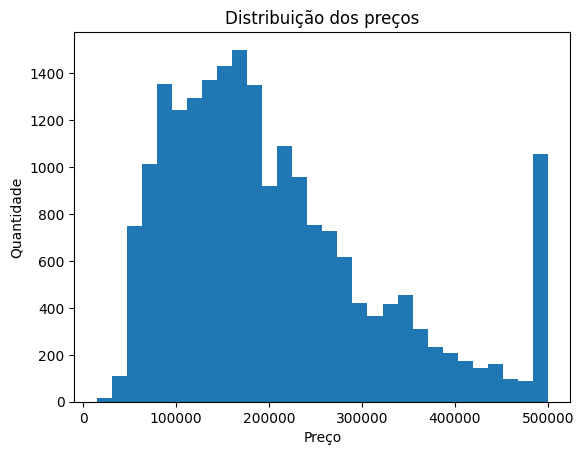

In [7]:
plt.hist(df['median_house_value'], bins=30)
plt.xlabel('Preço')
plt.ylabel('Quantidade')
plt.title('Distribuição dos preços')
plt.show()

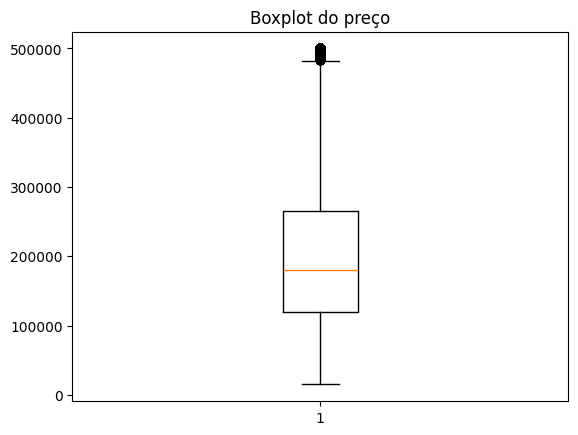

In [8]:
plt.boxplot(df['median_house_value'].dropna())
plt.title('Boxplot do preço')
plt.show()

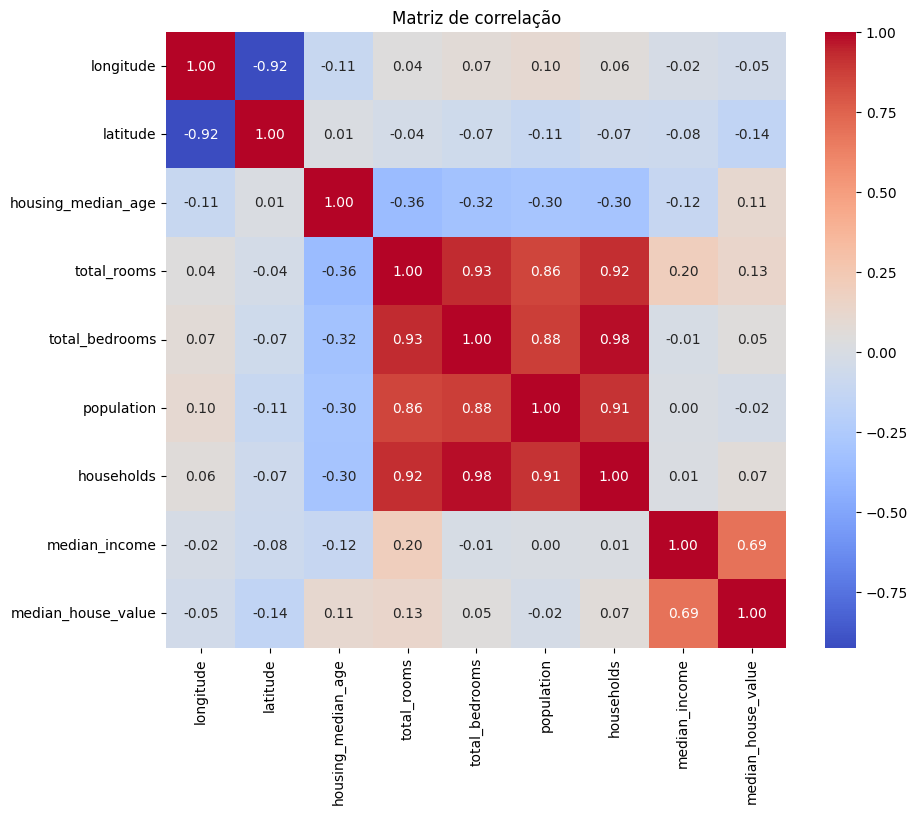

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Matriz de correlação')
plt.show()

## 5. Etapa 3 — Identificação de Outliers (Método IQR)

In [10]:
def iqr_outliers(col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (df[col] < low) | (df[col] > high)
    print(col, '-> outliers:', mask.sum(), f'({100*mask.sum()/len(df):.2f}%)')
    return low, high

for col in ['median_house_value','total_rooms','total_bedrooms','population','households','median_income']:
    iqr_outliers(col)

median_house_value -> outliers: 1071 (5.19%)
total_rooms -> outliers: 1287 (6.24%)
total_bedrooms -> outliers: 1271 (6.16%)
population -> outliers: 1196 (5.79%)
households -> outliers: 1220 (5.91%)
median_income -> outliers: 681 (3.30%)


## 6. Etapa 4 — Tratamento dos Dados

In [11]:
# Tratamento de valores ausentes: imputação pela mediana
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Remove valor "capado" (artefato de coleta em 500001)
df = df[df['median_house_value'] < 500001]

# Remove outliers do alvo pelo método IQR
Q1, Q3 = df['median_house_value'].quantile(0.25), df['median_house_value'].quantile(0.75)
IQR = Q3 - Q1
low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df = df[(df['median_house_value'] >= low) & (df['median_house_value'] <= high)]

print('Shape após tratamento:', df.shape)
df.isnull().sum()

Shape após tratamento: (19324, 10)


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## 7. Etapa 5 — Preparação dos Dados
Codificação da variável categórica, separação em treino/teste e padronização 
das variáveis (necessária para o SVR, que é sensível à escala dos dados).

In [12]:
# Codificação da variável categórica
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# Separação em X (features) e y (alvo)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Divisão treino/teste (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Padronização (fit apenas no treino, para evitar vazamento de dados)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Treino:', X_train_scaled.shape, '| Teste:', X_test_scaled.shape)

Treino: (15459, 12) | Teste: (3865, 12)


## 8. Etapa 6 — Modelo Baseline
Treinamento de um SVR com parâmetros padrão, para servir de referência antes 
da otimização de hiperparâmetros.

In [13]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score

modelo_baseline = SVR()
modelo_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = modelo_baseline.predict(X_test_scaled)

r2_baseline = r2_score(y_test, y_pred_baseline)
print('R² baseline:', r2_baseline)

R² baseline: -0.014356883870077608


## 9. Etapa 7 — Comparação de Kernels
Comparação do desempenho do SVR com diferentes kernels (linear, rbf, poly), 
mantendo os demais parâmetros no padrão.

In [14]:
for k in ['linear', 'rbf', 'poly']:
    m = SVR(kernel=k)
    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)
    print(f'{k} -> R²: {r2_score(y_test, pred):.4f}')

linear -> R²: 0.1560
rbf -> R²: -0.0144
poly -> R²: -0.0151


## 10. Etapa 8 — Otimização de Hiperparâmetros (GridSearchCV)
Devido ao alto custo computacional do SVR em bases grandes, a busca em grade é 
realizada sobre uma amostra de 4.000 registros do conjunto de treino, e o melhor 
modelo encontrado é então re-treinado com a base de treino completa.

In [15]:
from sklearn.model_selection import GridSearchCV
import numpy as np

parametros = {
    'C': [100, 1000, 5000, 10000],
    'epsilon': [0.05, 0.1, 0.2],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}

idx = np.random.RandomState(42).choice(len(X_train_scaled), 4000, replace=False)

grid = GridSearchCV(SVR(), parametros, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled[idx], y_train.values[idx])

print('Melhores parâmetros:', grid.best_params_)
print('Melhor R² (validação cruzada):', grid.best_score_)

Melhores parâmetros: {'C': 10000, 'epsilon': 0.05, 'gamma': 'scale', 'kernel': 'rbf'}
Melhor R² (validação cruzada): 0.6467497242888288


## 11. Etapa 9 — Modelo Final e Avaliação
Re-treinamento do SVR com os melhores hiperparâmetros encontrados, utilizando 
todo o conjunto de treino, e avaliação no conjunto de teste.

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

modelo_final = grid.best_estimator_
modelo_final.fit(X_train_scaled, y_train)  # treina com TODO o treino
y_pred_final = modelo_final.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred_final)
mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print(f'R²: {r2:.4f}')
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

R²: 0.6833
MAE: 36212.80
RMSE: 51689.48


**Resultado final:** O modelo SVR otimizado (kernel rbf, C=10000, epsilon=0.05, 
gamma='scale'), treinado com todo o conjunto de treino, atingiu R² = 0,6833 no 
conjunto de teste — superando a meta de 0,65 estabelecida. O erro médio absoluto 
(MAE) foi de US$ 36.212,80 e o RMSE de US$ 51.689,48.

## 12. Gráfico: Valores Reais x Valores Previstos

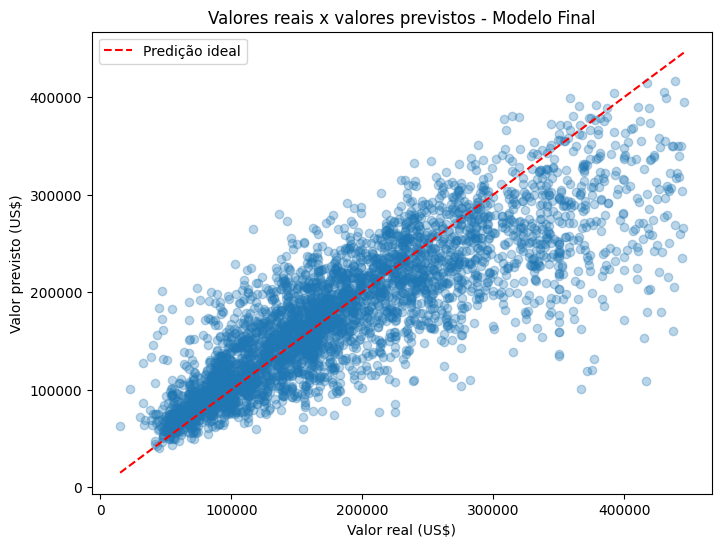

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_final, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Predição ideal')
plt.xlabel('Valor real (US$)')
plt.ylabel('Valor previsto (US$)')
plt.title('Valores reais x valores previstos - Modelo Final')
plt.legend()
plt.show()

**Observação do gráfico:** Os pontos se concentram próximos à linha de predição 
ideal, especialmente na faixa de preços mais baixos e médios (até ~US$ 250.000), 
onde há maior densidade de dados. Em faixas de preço mais altas, o modelo tende a 
subestimar levemente os valores, refletindo a menor quantidade de exemplos disponíveis 
nessa região da distribuição.

## 13. Conclusão
O modelo SVR, após tratamento de valores ausentes, remoção de outliers, padronização 
e otimização de hiperparâmetros via GridSearchCV, atingiu R² = 0,6833 no conjunto de 
teste, superando a meta estabelecida de 0,65. O parâmetro C revelou-se o mais 
determinante para o desempenho do modelo, sendo necessário um valor bem acima do 
padrão (C=10000) para que o kernel RBF capturasse adequadamente a relação entre as 
variáveis explicativas e o preço dos imóveis.